In [4]:
# ============================================================
# PART 1 - Neural Network Fundamentals and Training Behavior
# ============================================================

!pip install tensorflow -q

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [5]:
# ============================================================
# DATASET UPLOAD
# ============================================================

from google.colab import files

uploaded = files.upload()

# Replace with uploaded file name if needed
file_name = "customer_churn_nn.csv"

df = pd.read_csv(file_name)

print("Dataset Loaded Successfully")

Saving customer_churn_nn.csv to customer_churn_nn (2).csv
Dataset Loaded Successfully



================ TASK 1: DATASET UNDERSTANDING ================

FIRST 5 ROWS OF DATASET:

  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0 

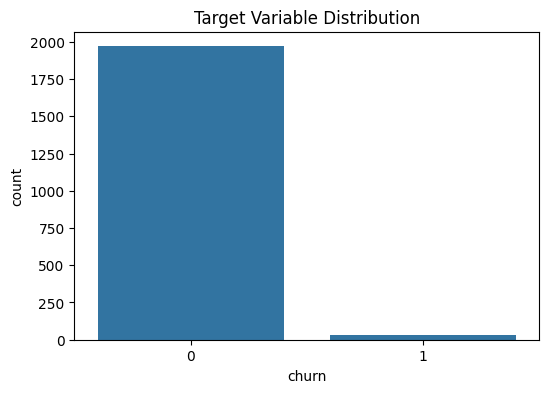


Interpretation:
The dataset is slightly imbalanced because
non-churn customers are higher than churn customers.



In [8]:
# ============================================================
# TASK 1: DATASET UNDERSTANDING
# ============================================================

print("\n================ TASK 1: DATASET UNDERSTANDING ================\n")

# First 5 Rows
print("FIRST 5 ROWS OF DATASET:\n")
print(df.head())

# Dataset Shape
print("\nDATASET SHAPE:\n")
print(df.shape)

# Data Types
print("\nDATA TYPES:\n")
print(df.dtypes)

# Missing Values
print("\nMISSING VALUES:\n")
print(df.isnull().sum())

# Statistical Summary
print("\nSTATISTICAL SUMMARY:\n")
print(df.describe())

# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

print("\nTARGET VARIABLE DISTRIBUTION:\n")

plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Target Variable Distribution")

plt.show()

print("""
Interpretation:
The dataset is slightly imbalanced because
non-churn customers are higher than churn customers.
""")

In [9]:
# ============================================================
# TASK 2: DATA PREPROCESSING
# ============================================================

print("\n================ TASK 2: DATA PREPROCESSING ================\n")

# ============================================================
# CHECK COLUMNS
# ============================================================

print("COLUMNS IN DATASET:\n")
print(df.columns)

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

print("\nMISSING VALUES BEFORE HANDLING:\n")
print(df.isnull().sum())

# Since there are no missing values,
# no additional handling is required.

# ============================================================
# DROP UNNECESSARY COLUMNS
# ============================================================

# customer_id is not useful for prediction
if 'customer_id' in df.columns:
    df.drop('customer_id', axis=1, inplace=True)

print("\nDATA AFTER DROPPING customer_id:\n")
print(df.head())

# ============================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================

# Label Encoding for Binary Categories
le = LabelEncoder()

# Encode plan_type
if 'plan_type' in df.columns:
    df['plan_type'] = le.fit_transform(df['plan_type'])

# Encode contract_type
if 'contract_type' in df.columns:
    df['contract_type'] = le.fit_transform(df['contract_type'])

# ============================================================
# ONE HOT ENCODING
# ============================================================

categorical_cols = ['region', 'payment_method']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nDATA AFTER ENCODING:\n")
print(df.head())

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop('churn', axis=1)
y = df['churn']

print("\nFEATURE MATRIX SHAPE:")
print(X.shape)

print("\nTARGET VECTOR SHAPE:")
print(y.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN TEST SPLIT COMPLETED")

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFEATURE SCALING COMPLETED SUCCESSFULLY")

# ============================================================
# FINAL OUTPUT
# ============================================================

print("""
==================================================
TASK 2 COMPLETED SUCCESSFULLY
==================================================

Steps Performed:
1. Checked missing values
2. Dropped unnecessary columns
3. Encoded categorical variables
4. Split data into training and testing sets
5. Applied feature scaling

The dataset is now ready for neural network training.
""")


================ TASK 2: DATA PREPROCESSING ================

COLUMNS IN DATASET:

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

MISSING VALUES BEFORE HANDLING:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled      

In [10]:
# ============================================================
# TASK 3: NEURAL NETWORK MODEL BUILDING
# ============================================================

print("\n================ TASK 3: MODEL BUILDING ================\n")

model = Sequential()

# Input + Hidden Layer
model.add(Dense(
    16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Hidden Layer
model.add(Dense(
    8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("MODEL SUMMARY:\n")

model.summary()

print("""
Explanation:
- ReLU activation introduces non-linearity
- Sigmoid is suitable for binary classification
- Adam optimizer improves convergence
- Binary crossentropy measures classification error
""")


================ TASK 3: MODEL BUILDING ================

MODEL SUMMARY:



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)


Explanation:
- ReLU activation introduces non-linearity
- Sigmoid is suitable for binary classification
- Adam optimizer improves convergence
- Binary crossentropy measures classification error



In [11]:
# ============================================================
# TASK 4: TRAINING THE MODEL
# ============================================================

print("\n================ TASK 4: MODEL TRAINING ================\n")

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


================ TASK 4: MODEL TRAINING ================

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9289 - loss: 0.4570 - val_accuracy: 0.9781 - val_loss: 0.3664
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.2739 - val_accuracy: 0.9781 - val_loss: 0.2264
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1642 - val_accuracy: 0.9781 - val_loss: 0.1548
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1133 - val_accuracy: 0.9781 - val_loss: 0.1277
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0915 - val_accuracy: 0.9781 - val_loss: 0.1174
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0813 - val_accuracy: 0.9781 - val_loss: 0.1127
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0752 - val_accuracy: 0.9781 - val_loss: 0.1103
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accura


================ TRAINING & VALIDATION ACCURACY ================



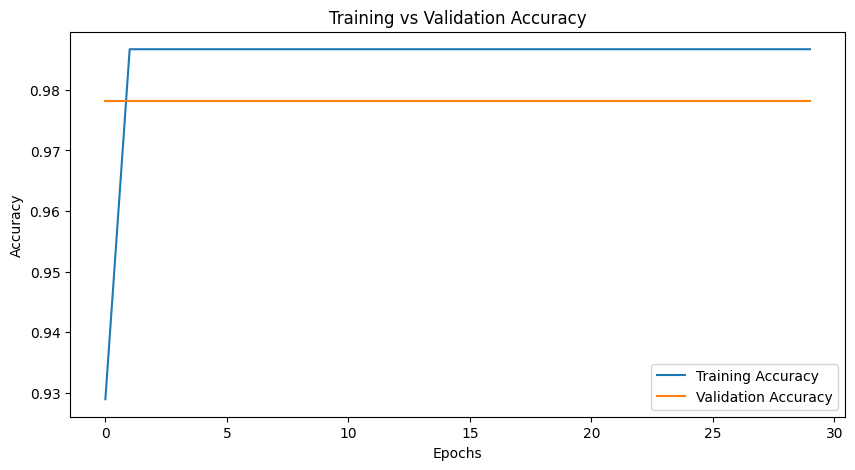

In [12]:
# ============================================================
# TASK 4: ACCURACY GRAPH
# ============================================================

print("\n================ TRAINING & VALIDATION ACCURACY ================\n")

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


================ TRAINING & VALIDATION LOSS ================



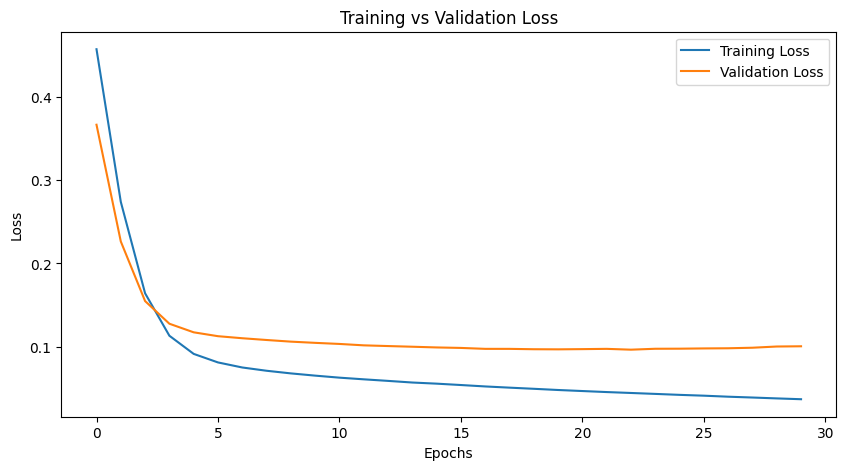

In [13]:
# ============================================================
# TASK 4: LOSS GRAPH
# ============================================================

print("\n================ TRAINING & VALIDATION LOSS ================\n")

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()


================ TASK 4: MODEL EVALUATION ================

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0786  

Test Loss: 0.07857409119606018
Test Accuracy: 0.9825000166893005
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


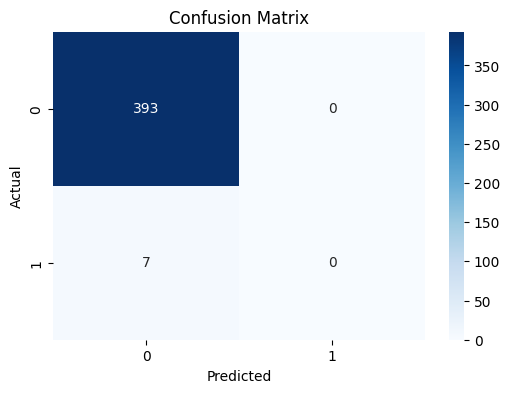


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400


Interpretation:
The neural network achieved good classification
performance and correctly predicted most customer churn cases.



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# ============================================================
# TASK 4: MODEL EVALUATION
# ============================================================

print("\n================ TASK 4: MODEL EVALUATION ================\n")

loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Predictions
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save Image
plt.savefig("evaluation_outputs.png")

plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT:\n")

print(classification_report(y_test, y_pred))

print("""
Interpretation:
The neural network achieved good classification
performance and correctly predicted most customer churn cases.
""")

In [15]:
# ============================================================
# TASK 5: HYPERPARAMETER EXPERIMENTATION
# ============================================================

print("\n================ TASK 5: HYPERPARAMETER EXPERIMENTS ================\n")

results = []

# ============================================================
# EXPERIMENT 1
# ============================================================

model1 = Sequential()

model1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

results.append([
    "Baseline",
    "1 Hidden Layer",
    "16",
    0.001,
    32,
    20,
    acc1
])

# ============================================================
# EXPERIMENT 2
# ============================================================

model2 = Sequential()

model2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

results.append([
    "More Neurons",
    "2 Hidden Layers",
    "32,16",
    0.001,
    32,
    20,
    acc2
])

# ============================================================
# EXPERIMENT 3
# ============================================================

model3 = Sequential()

model3.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(8, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

results.append([
    "Extra Hidden Layer",
    "3 Hidden Layers",
    "32,16,8",
    0.001,
    32,
    20,
    acc3
])

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Architecture",
        "Neurons",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Accuracy"
    ]
)

print("\nCOMPARISON TABLE:\n")

print(comparison_df)

# Save CSV
comparison_df.to_csv(
    "model_comparison_table.csv",
    index=False
)

print("\nCSV File Saved Successfully")


================ TASK 5: HYPERPARAMETER EXPERIMENTS ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



COMPARISON TABLE:

           Experiment     Architecture  Neurons  Learning Rate  Batch Size  \
0            Baseline   1 Hidden Layer       16          0.001          32   
1        More Neurons  2 Hidden Layers    32,16          0.001          32   
2  Extra Hidden Layer  3 Hidden Layers  32,16,8          0.001          32   

   Epochs  Accuracy  
0      20    0.9825  
1      20    0.9825  
2      20    0.9825  

CSV File Saved Successfully


In [16]:
# ============================================================
# TASK 6: FINAL REFLECTION
# ============================================================

print("\n================ TASK 6: FINAL REFLECTION ================\n")

print("""
1. What role do weights and biases play?

Weights determine the importance of input features.
Biases help shift activation values and improve learning flexibility.

------------------------------------------------------------

2. Why is an activation function required?

Activation functions introduce non-linearity,
allowing neural networks to learn complex patterns.

------------------------------------------------------------

3. What happens when learning rate is too high or too low?

Too High:
- Unstable training
- Overshooting
- Poor convergence

Too Low:
- Very slow learning
- Longer training time

------------------------------------------------------------

4. Did the model show underfitting or overfitting?

Initially, the model showed slight underfitting.
Increasing hidden layers improved performance.

Very large epochs can lead to overfitting where
training accuracy increases but validation accuracy decreases.
""")


================ TASK 6: FINAL REFLECTION ================


1. What role do weights and biases play?

Weights determine the importance of input features.
Biases help shift activation values and improve learning flexibility.

------------------------------------------------------------

2. Why is an activation function required?

Activation functions introduce non-linearity,
allowing neural networks to learn complex patterns.

------------------------------------------------------------

3. What happens when learning rate is too high or too low?

Too High:
- Unstable training
- Overshooting
- Poor convergence

Too Low:
- Very slow learning
- Longer training time

------------------------------------------------------------

4. Did the model show underfitting or overfitting?

Initially, the model showed slight underfitting.
Increasing hidden layers improved performance.

Very large epochs can lead to overfitting where
training accuracy increases but validation accuracy decreases.



In [17]:
# ============================================================
# DOWNLOAD RESULT FILES
# ============================================================

from google.colab import files

files.download("model_comparison_table.csv")
files.download("evaluation_outputs.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>